In [ ]:
models/run9/skip-torch-4D-y5+y13_y6+y14-37b32f55--16-32-leaky_relu-1024-adam-exp-schedule-mse-val_mse-92.194010-99.687439/test-results-37b32f55-92.194010-99.687439.csv

In [1]:
config = {
    "model_type": "skip",
    "input_shape": 4,
    "amplitude_shape": 36,
    "data_dir": "/scratch/akula.ha/dataset", 
    "seed": 42,
    "var_y": ["y5+y13", "y6+y14"],
    "activation": "leaky_relu", 
    "width": 32, 
    "depth": 16, 
    "skip_block_layers": 1, 
    "beta": 0,
    "alpha": 0,
    "normal_scaled": False,
    "lr_decay_type": "exp",
    "initial_lr": 0.001,
    "final_lr": 1e-06,
    "decay_steps": 120000, 
    "train-sample-size": 1000000,
    "validate-sample-size": 500000,
    "test-sample-size": 500000,
    "use_MC_sample": False,
    "batch_size": 512,
    "steps_per_epoch": 2000,
    "early_stopping_start_epoch": 50, 
    "patience": 100, 
    "monitor": "val_mse",
    "loss": "mse",
    "gradient_clipping": True,
    "verbose": 1,
    "base_directory": "../models/",
    "epochs": 1000, 
    "model-uuid": "UUID"
}

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql import dataframe
from pyspark.sql.types import StructType, StructField, DoubleType
from sklearn import metrics
import time
import sys
import logging
import uuid
import os
import shutil
import json
import argparse
import pytorch_model_summary as pms

In [3]:
def init_torch(config):
    ''' function for initializing the seeds
        arguments:
            config: the configuration file
    '''
    gen = torch.manual_seed(config['seed'])
    torch.set_default_dtype(torch.float64)
    
    device = get_device()

    if device.type == 'cpu':
        torch.set_num_threads(64)
        # torch.set_num_interop_threads(1)

    logging.info(f' torch is using {device}')
    
    return device

In [4]:
def get_device():
    ''' function to get the device the NN is running on, CPU or GPU
    '''
    if torch.cuda.is_available():
        device = torch.device("cuda:0")
    else: 
        device = torch.device("cpu")
        
    return device

In [5]:
device = init_torch(config)

In [6]:
import re

In [7]:
def load_data(config):
    """ Load the data using pyspark
        arguments:
            config: the configuration file
        returns:
            df['train']: the training dataframe
            df['validate']: the validation data set
            df['test']: the testing data set
            spark: the spark session
    """
    
    # Spark session and configuration
    logging.info(' creating Spark session')
    spark = (SparkSession.builder.master("local[48]")
             .config('spark.executor.instances', 16)
             .config('spark.executor.cores', 16)
             .config('spark.executor.memory', '10g')
             .config('spark.driver.memory', '15g')
             .config('spark.memory.offHeap.enabled', True)
             .config('spark.memory.offHeap.size', '20g')
             .config('spark.dirver.maxResultSize', '20g')
             .config('spark.debug.maxToStringFields', 100)
             .appName("amp.hell").getOrCreate())

    # Enable Arrow-based columnar data 
    spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
    spark.conf.set(
        "spark.sql.execution.arrow.pyspark.fallback.enabled", "true"
    )
    logging.info(' Spark initialized')
    
    # read the data into a spark frame
    start = time.time()
    path = config['data_dir']
    if path[-1] != '/':
        path = path + '/'
    input_var = ['x'+str(i+1) for i in range(config['input_shape'])]
    target_var = ['y'+str(i+1) for i in range(config['amplitude_shape'])]

    header = input_var + target_var
    schema = StructType([StructField(header[i], DoubleType(), True) for i in range(config['input_shape']+config['amplitude_shape'])])

    df = {}
    df['train'] = spark.read.options(delimiter=',').schema(schema).format("csv").load(path+'train/*.csv.*', header='true')
    
    
    if config['var_y'] == 'all': config['var_y'] = df['train'].columns[config['input_shape']:]
    
    
    if config['use_MC_sample']:
        mc_suffix = '_mc'
    else:
        mc_suffix = ''
    df['validate'] = spark.read.options(delimiter=',').schema(schema).format("csv").load(path+'validate'+mc_suffix+'/*.csv.*', header='true')
    df['test'] = spark.read.options(delimiter=',').schema(schema).format("csv").load(path+'test'+mc_suffix+'/*.csv.*', header='true')

    logging.info(' data loaded into Spark session in {:.3f} seconds'.format(time.time() - start))
    
    # transfer the data to a pandas dataframe
    start = time.time()
    train_sample = min(config['train-sample-size'], df['train'].count())
    validate_sample = min(config['validate-sample-size'], df['validate'].count())
    test_sample = min(config['test-sample-size'], df['test'].count())
    
    ########################################################################
    # Assuming config['var_y'] is the list
    operators = ['+', '-', '*', '/']

    # List of items with operators
    with_operator = [item for item in config['var_y'] if any(op in item for op in operators)]
    print(with_operator)
    # List of items without operators
    without_operator = [item for item in config['var_y'] if all(op not in item for op in operators)]
    print(without_operator)
    
    # Split the items with operators into individual components
    split_items = [subitem for item in with_operator for subitem in re.split(r'\+|\-|\*|\/', item)]

    # Combine the split items with the items without operators
    combined_list = without_operator + split_items

    # Remove duplicates to get a unique list
    unique_list = list(set(combined_list))

    # Sort the list if you want it in a specific order (optional)
    unique_list.sort()
    
    ########################################################################
    
    df['train'] = df['train'].select(*input_var, *unique_list).limit(train_sample).toPandas() 
    df['validate'] = df['validate'].select(*input_var, *unique_list).limit(validate_sample).toPandas()
    df['test'] = df['test'].select(*input_var, *unique_list).limit(test_sample).toPandas()
    
    # Step 1: Perform the operations
    for key in ['train', 'validate', 'test']:
        for expr in config['var_y']:
            if any(op in expr for op in ['+', '-', '*', '/']):
                # Split the expression into individual components and operator
                components = re.split(r'(\+|\-|\*|\/)', expr)

                # Evaluate the expression and create a new column
                if len(components) == 3:  # This should match the pattern "y1 + y3"
                    col1, operator, col2 = components

                    if operator == '+':
                        df[key][expr] = df[key][col1] + df[key][col2]
                    elif operator == '-':
                        df[key][expr] = df[key][col1] - df[key][col2]
                    elif operator == '*':
                        df[key][expr] = df[key][col1] * df[key][col2]
                    elif operator == '/':
                        df[key][expr] = df[key][col1] / df[key][col2]

    # Filter split_items to keep only those that are also in without_operator
    filtered_items = [item for item in split_items if item not in without_operator]

    # Drop the filtered items from the DataFrames
    for key in ['train', 'validate', 'test']:
        df[key] = df[key].drop(columns=filtered_items, errors='ignore')

    
    logging.info(' training data shape: {} x {}'.format(df['train'].shape[0], df['train'].shape[1]))
    logging.info(' validation data shape: {} x {}'.format(df['validate'].shape[0], df['validate'].shape[1]))
    logging.info(' testing data shape: {} x {}'.format(df['test'].shape[0], df['test'].shape[1]))
    
    config['train-samples-used'] = df['train'].shape[1]
    config['validate-samples-used'] = df['validate'].shape[1]
    config['test-samples-used'] = df['test'].shape[1]

    logging.info(' data loaded into pandas dataframe in {:.3f} seconds'.format(time.time() - start))
    
    logger = spark._jvm.org.apache.log4j
    logging.getLogger("py4j.clientserver").setLevel(logging.WARN)

    return df, spark


In [18]:
def load_data(config):
    """ Load the data using pyspark
        arguments:
            config: the configuration file
        returns:
            df['train']: the training dataframe
            df['validate']: the validation data set
            df['test']: the testing data set
            spark: the spark session
    """
    
    # Spark session and configuration
    logging.info(' creating Spark session')
    spark = (SparkSession.builder.master("local[48]")
             .config('spark.executor.instances', 16)
             .config('spark.executor.cores', 16)
             .config('spark.executor.memory', '10g')
             .config('spark.driver.memory', '15g')
             .config('spark.memory.offHeap.enabled', True)
             .config('spark.memory.offHeap.size', '20g')
             .config('spark.dirver.maxResultSize', '20g')
             .config('spark.debug.maxToStringFields', 100)
             .appName("amp.hell").getOrCreate())

    # Enable Arrow-based columnar data 
    spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")
    spark.conf.set(
        "spark.sql.execution.arrow.pyspark.fallback.enabled", "true"
    )
    logging.info(' Spark initialized')
    
    # read the data into a spark frame
    start = time.time()
    path = config['data_dir']
    if path[-1] != '/':
        path = path + '/'
    input_var = ['x'+str(i+1) for i in range(config['input_shape'])]
    target_var = ['y'+str(i+1) for i in range(config['amplitude_shape'])]

    header = input_var + target_var
    schema = StructType([StructField(header[i], DoubleType(), True) for i in range(config['input_shape']+config['amplitude_shape'])])

    df = {}
    df['train'] = spark.read.options(delimiter=',').schema(schema).format("csv").load(path+'train/*.csv.*', header='true')
    
    if config['var_y'] == 'all': config['var_y'] = df['train'].columns[config['input_shape']:]
    
    
    if config['use_MC_sample']:
        mc_suffix = '_mc'
    else:
        mc_suffix = ''
    df['validate'] = spark.read.options(delimiter=',').schema(schema).format("csv").load(path+'validate'+mc_suffix+'/*.csv.*', header='true')
    df['test'] = spark.read.options(delimiter=',').schema(schema).format("csv").load(path+'test'+mc_suffix+'/*.csv.*', header='true')

    logging.info(' data loaded into Spark session in {:.3f} seconds'.format(time.time() - start))
    
    print("train", df['train'].count())
    print("val", df['validate'].count())
    print("test", df['test'].count())
    
    # transfer the data to a pandas dataframe
    start = time.time()
    train_sample = min(config['train-sample-size'], df['train'].count())
    validate_sample = min(config['validate-sample-size'], df['validate'].count())
    test_sample = min(config['test-sample-size'], df['test'].count())
    
    ########################################################################
    # Assuming config['var_y'] is the list
    operators = ['+', '-', '*', '/']

    # List of items with operators
    with_operator = [item for item in config['var_y'] if any(op in item for op in operators)]
    print(with_operator)
    # List of items without operators
    without_operator = [item for item in config['var_y'] if all(op not in item for op in operators)]
    print(without_operator)
    
    # Split the items with operators into individual components
    split_items = [subitem for item in with_operator for subitem in re.split(r'\+|\-|\*|\/', item)]

    # Combine the split items with the items without operators
    combined_list = without_operator + split_items

    # Remove duplicates to get a unique list
    unique_list = list(set(combined_list))

    # Sort the list if you want it in a specific order (optional)
    unique_list.sort()
    
    ########################################################################
    
    df['train'] = df['train'].select(*input_var, *unique_list).toPandas() 
    df['validate'] = df['validate'].select(*input_var, *unique_list).toPandas()
    df['test'] = df['test'].select(*input_var, *unique_list).toPandas()
    
    # Step 1: Perform the operations
    for key in ['train', 'validate', 'test']:
        for expr in config['var_y']:
            if any(op in expr for op in ['+', '-', '*', '/']):
                # Split the expression into individual components and operator
                components = re.split(r'(\+|\-|\*|\/)', expr)

                # Evaluate the expression and create a new column
                if len(components) == 3:  # This should match the pattern "y1 + y3"
                    col1, operator, col2 = components

                    if operator == '+':
                        df[key][expr] = df[key][col1] + df[key][col2]
                    elif operator == '-':
                        df[key][expr] = df[key][col1] - df[key][col2]
                    elif operator == '*':
                        df[key][expr] = df[key][col1] * df[key][col2]
                    elif operator == '/':
                        df[key][expr] = df[key][col1] / df[key][col2]

    # Filter split_items to keep only those that are also in without_operator
    filtered_items = [item for item in split_items if item not in without_operator]

    # Drop the filtered items from the DataFrames
    for key in ['train', 'validate', 'test']:
        df[key] = df[key].drop(columns=filtered_items, errors='ignore')

    
    logging.info(' training data shape: {} x {}'.format(df['train'].shape[0], df['train'].shape[1]))
    logging.info(' validation data shape: {} x {}'.format(df['validate'].shape[0], df['validate'].shape[1]))
    logging.info(' testing data shape: {} x {}'.format(df['test'].shape[0], df['test'].shape[1]))
    
    config['train-samples-used'] = df['train'].shape[1]
    config['validate-samples-used'] = df['validate'].shape[1]
    config['test-samples-used'] = df['test'].shape[1]

    logging.info(' data loaded into pandas dataframe in {:.3f} seconds'.format(time.time() - start))
    
    logger = spark._jvm.org.apache.log4j
    logging.getLogger("py4j.clientserver").setLevel(logging.WARN)

    return df, spark


In [19]:
df, spark = load_data(config)

train 3393726
val 1699218
test 1696607


['y5+y13', 'y6+y14']
[]


In [20]:
df

{'train':                    x1        x2        x3        x4      y5+y13      y6+y14
 0        5.308962e-08  0.309913  0.050721  0.629043  -33.250872   27.628886
 1        3.505005e-07  0.281701  0.997791  0.482102 -197.379386  209.858618
 2        4.480013e-07  0.609822  0.147178  0.852029  172.271554 -189.373238
 3        6.298025e-07  0.258704  0.408208  0.122103 -202.259694  213.956168
 4        1.014703e-06  0.417312  0.940159  0.743944  -71.831401   75.899362
 ...               ...       ...       ...       ...         ...         ...
 3393721  9.937817e-01  0.520471  0.116823  0.381197   -0.576241   -0.248833
 3393722  9.970094e-01  0.248280  0.539416  0.161634   -2.539606    1.213359
 3393723  9.974963e-01  0.255944  0.522281  0.471605   -4.146113    0.949956
 3393724  9.976171e-01  0.892835  0.290839  0.270442   14.821786   -3.782874
 3393725  9.990412e-01  0.747992  0.462169  0.535807    4.187322   -1.006427
 
 [3393726 rows x 6 columns],
 'validate':                    x1  

In [11]:
df

{'train':                    x1        x2        x3        x4      y5+y13      y6+y14
 0        5.308962e-08  0.309913  0.050721  0.629043  -33.250872   27.628886
 1        3.505005e-07  0.281701  0.997791  0.482102 -197.379386  209.858618
 2        4.480013e-07  0.609822  0.147178  0.852029  172.271554 -189.373238
 3        6.298025e-07  0.258704  0.408208  0.122103 -202.259694  213.956168
 4        1.014703e-06  0.417312  0.940159  0.743944  -71.831401   75.899362
 ...               ...       ...       ...       ...         ...         ...
 3393721  9.937817e-01  0.520471  0.116823  0.381197   -0.576241   -0.248833
 3393722  9.970094e-01  0.248280  0.539416  0.161634   -2.539606    1.213359
 3393723  9.974963e-01  0.255944  0.522281  0.471605   -4.146113    0.949956
 3393724  9.976171e-01  0.892835  0.290839  0.270442   14.821786   -3.782874
 3393725  9.990412e-01  0.747992  0.462169  0.535807    4.187322   -1.006427
 
 [3393726 rows x 6 columns],
 'validate':                    x1  

In [10]:
def build_data_loaders(df, config):
    ''' function to build the data loaders
        arguments:
            df: dictionary of pandas dataframe for test, validation, and train
            config: configuration file
        returns:
            train_loader: the training set loader
            validation_loader: the validation set loader
            test_loader: the test set loader
    '''
    
    # slice and dice the data into train, validation and test sets
    df_test_data =  df['test']
    df_validation_data = df['validate']
    df_train_data = df['train']

    test_data = df_to_tensor(df_test_data, config)
    validation_data = df_to_tensor(df_validation_data, config)
    train_data = df_to_tensor(df_train_data, config)

    # load the data into torch tensor batches
    batch = config["batch_size"]
    numworkers = 2 if get_device().type == 'cpu' else 0
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch, shuffle=True, num_workers=numworkers, drop_last=True)
    validation_loader = torch.utils.data.DataLoader(validation_data, batch_size=batch, shuffle=True, num_workers=numworkers, drop_last=True)
    test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch, shuffle=False, num_workers=numworkers, drop_last=True)
    
    return train_loader, validation_loader, test_loader


In [11]:

class df_to_tensor(torch.utils.data.Dataset):
    ''' class to convert dataframe to torch tensor
    '''
 
    def __init__(self, df, config):
        self.df = df.copy(deep = True)
        
        # extract x and scale
        x = df.iloc[:, :config['input_shape']]
        df['x1'] = df['x1'].apply(lambda x: x_scale(x))
        
        # extract y
        # if config['var_y'] == 'all':
        #     y = df.iloc[:, config['input_shape']:]
        # else:
        y = df[config['var_y']]
        
        # number of targets
        config['n_targets'] = y.shape[1]
            
        # scale y
        config['scaling'] = {}
        for column in y.columns:
            y[column] = y[column].apply(lambda y: y_scale(y))
            if config['normal_scaled']:
                y[column] = normalize(y, config, column)

        # put them in tensors. Note: the reshaping of y.
        self.x = torch.tensor(x.values, dtype=torch.float64).to(get_device())
        self.y = torch.tensor(y.values, dtype=torch.float64).reshape(-1, config['n_targets']).to(get_device())
 
    def __len__(self):
        return len(self.x)
   
    def __getitem__(self,idx):
        return self.x[idx], self.y[idx]
    
    

In [12]:
def normalize(df, config, var_y):
    """ a function to normaliza the target distribution
        arguments:
            df: dataframe containing the target variable
            config: the config file with the run configuration
            var_y: the variable to be normalized
    """
    config['scaling'][var_y] = {}
    config['scaling'][var_y]["mu"] = df[var_y].mean()
    config['scaling'][var_y]["sigma"] = df[var_y].std()
    
    return (df[var_y] - config['scaling'][var_y]["mu"])/config['scaling'][var_y]["sigma"]


def x_scale(x, p=7.5):
    ''' function for scaling x1
        argument:
            x: the input variable
            p: the scaling factor (default: 7.5)
        returns:
            the scaled variable
    '''
    return 1/p * np.log(1 + x * (np.exp(p) - 1))
                        
    
def y_scale(y):
    ''' function for scaling x1
        argument:
            y: the input variable
        returns:
            the scaled variable
    '''
    return np.log(1 + y) if y >= 0 else -np.log(1 - y)


def y_unscale(y):
    ''' function for scaling x1
        argument:
            y: the input variable
        returns:
            the scaled variable
    '''
    return np.exp(y) - 1 if y >= 0 else 1 - np.exp(-y)

In [13]:
df

{'train':                   x1        x2        x3        x4      y5+y13      y6+y14
 0       5.308962e-08  0.309913  0.050721  0.629043  -33.250872   27.628886
 1       3.505005e-07  0.281701  0.997791  0.482102 -197.379386  209.858618
 2       4.480013e-07  0.609822  0.147178  0.852029  172.271554 -189.373238
 3       6.298025e-07  0.258704  0.408208  0.122103 -202.259694  213.956168
 4       1.014703e-06  0.417312  0.940159  0.743944  -71.831401   75.899362
 ...              ...       ...       ...       ...         ...         ...
 999995  2.928059e-03  0.380932  0.461895  0.042631  -33.510085   97.116026
 999996  2.928432e-03  0.410596  0.110243  0.488896   11.586495  -35.741611
 999997  2.929111e-03  0.505405  0.257753  0.821399   28.625589  -72.939524
 999998  2.931479e-03  0.033489  0.697654  0.752763 -338.836902  333.992802
 999999  2.931944e-03  0.611781  0.306585  0.878891   43.415572 -107.097179
 
 [1000000 rows x 6 columns],
 'validate':                   x1        x2     

In [14]:
train_loader, validation_loader, test_loader = build_data_loaders(df,config)

/tmp/ipykernel_47808/3488228483.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y[column] = y[column].apply(lambda y: y_scale(y))
/tmp/ipykernel_47808/3488228483.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y[column] = y[column].apply(lambda y: y_scale(y))
/tmp/ipykernel_47808/3488228483.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

In [15]:
def test_model(model, test_data, config):
    ''' function for testing the model
        arguments:
            model: the pytorch model to nbe trained
            test_data: the test data loader
            config: the configurations file
        returns:
            the absolute error
            the R2 score
    '''
    
    for i, data in enumerate(test_data):
        
        # forward prop
        x, y = data
        y_p = model(x)
        
        # store data
        if i == 0:
            x_test = x.cpu().detach().numpy()
            y_test = y.cpu().detach().numpy()
            y_pred = y_p.cpu().detach().numpy()
        else: 
            x_test = np.vstack((x_test, x.cpu().detach().numpy()))
            y_test = np.vstack((y_test, y.cpu().detach().numpy()))
            y_pred = np.vstack((y_pred, y_p.cpu().detach().numpy()))
        
    
    # accuracy
    y_test = np.array(y_test).reshape(-1, config['n_targets'])
    y_pred = np.array(y_pred).reshape(-1, config['n_targets'])
    abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
    r2_score = metrics.r2_score(y_test, y_pred)*100
    
    # save test results
    df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])
    
    # unscale the target
    scaled_cname = [s + '_scaled' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)
    for col in df_pred.columns[4:]:
        df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_test_real = pd.DataFrame(np.vectorize(y_unscale)(y_test), columns=config['var_y']) # 
    # df_pred = pd.concat([df_pred, y_test_real], axis=1)
    y_test_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # stuff in the scaled predictions
    pred_cname = [s + '_scaled_pred' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)
    
    # stuff in the unscaled predictions
    pred_cname = [s + '_pred' for s in config['var_y']]
    for col in df_pred.columns[-config['n_targets']:]:
        df_pred[col[:-12]+'_pred'] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_pred_real = pd.DataFrame(np.vectorize(y_unscale)(y_pred), columns=pred_cname) # .apply(lambda y: y_unscale(y))
    # df_pred = pd.concat([df_pred, y_pred_real], axis=1)
    y_pred_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # calculate the deltas for the scaled and unscaled targets
    scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
    delta_cname = ['delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)
    
    #same the whole dataframe
    #df_pred.to_csv(config['directory']+'/test-results-'+config['model-uuid']+'-'+f'{abs_score:.6f}-{r2_score:.6f}.csv')
    
    # plot all the scaled and real deltas
    """for c in scaled_delta_cname:
        make_error_plot(config, df_pred, col=c)
    for c in delta_cname:
        make_error_plot(config, df_pred, col=c)"""
        
    config['test_metrics'] = {}
    config['test_metrics']['r2'] = {}
    config['test_metrics']['abs_score'] = {}
    num_vars = len(config['var_y'])
    base_length = config['input_shape'] + num_vars
    for i in range(base_length, base_length + num_vars):
        test = df_pred.iloc[:,i].values
        pred = df_pred.iloc[:,i + 2 * num_vars].values
        config['test_metrics']['r2'][config['var_y'][i - base_length]] = metrics.r2_score(test, pred)*100
        config['test_metrics']['abs_score'][config['var_y'][i - base_length]] = 100 - np.abs(df_pred.iloc[:,i + 4 * num_vars].mean())
    
    config['test_metrics']['r2']['model'] = r2_score
    config['test_metrics']['abs_score']['model'] = abs_score
    
    return abs_score, r2_score

## Model classes

In [16]:
class EarlyStopping:
    ''' class for early stopping with patience
    '''
    def __init__(self, m_path, patience=1, min_delta=0):
        '''
            arguments:
                m_path: the model path where the checkpoints go
                patience: the number of epochs the patience lasts
                min_delta: the minimum change that is monitored
        '''
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = np.inf
        self.m_path = m_path
        
    def reset_counter(self):
        ''' function to reset the counter
        '''
        self.counter = 0

    def early_stop(self, model, validation_loss, epoch, config):
        ''' function to check for the early stopping threshold
            arguments:
                model: the torch model
                validation_loss: the validation loss
        '''
        if epoch > config['early_stopping_start_epoch']: 
            if validation_loss < self.min_validation_loss:
                self.min_validation_loss = validation_loss
                torch.save(model.state_dict(), self.m_path)
                config['n_training_epochs'] = epoch
                self.counter = 0
            elif validation_loss > (self.min_validation_loss + self.min_delta):
                self.counter += 1
                if self.counter >= self.patience:
                    return True
            return False
        else:
            return False
    
    
class skip_block(torch.nn.Module):
    """ the basic building block of a dnn with skip connections
        arguments:
            x: the input
            width: the width of the hidden layers
            activation: the activation function: 'relu', 'elu', 'swish' (silu), 'leaky_relu', 'softplus'
            squeeze: a boolean specifying wheher the skip units are squeezed
        returns:
            res: the skip net block
    """
    def __init__(self, input_shape, width, activation, stream = False, n_layers=1):
        ''' init function
            arguments:
                input_shape: the input shape of the block
                width: the width of the block
                activation: the activation function
                stream: build a residual stream or not (default: false)
                n_layers: the number of layers in the block (default: 1)
        '''
        super(skip_block, self).__init__()
        self.input_shape = input_shape
        self.width = width
        self.stream = stream
        
        self.input = torch.nn.Linear(self.input_shape, self.width)
        self.fc_module = torch.nn.ModuleList([torch.nn.Linear(self.width, self.width) for i in range(n_layers)])
        
        if self.stream:
            self.linear = torch.nn.Linear(self.width, self.input_shape)
        else:    
            self.linear = torch.nn.Linear(self.width, self.width)
            
        if self.input_shape != self.width:
            self.reshape = torch.nn.Linear(self.input_shape, self.width, bias=False)
        
        self.act = activation
        
    def forward(self, x):
        ''' forward propagation
        '''
        y = self.act(self.input(x))
        for l in self.fc_module:
            y = self.act(l(y))
        if self.stream:
            y = self.act(self.linear(y))
            y += x
            return y
        else:
            y = self.linear(y)
            if self.input_shape != self.width:
                residual = self.reshape(x)
            else:
                residual = x
            y += residual

            return self.act(y)
        
        
def getActivation(config):
    ''' function for defining the activation function
        argument:
            config: the configurations file
        returns
            the specified activations function
    '''
    if config["activation"] == 'leaky_relu':
        return torch.nn.LeakyReLU()
    elif config["activation"] == 'relu':
        return torch.nn.ReLU()
    if config["activation"] == 'softplus':
        return torch.nn.Softplus()
    if config["activation"] == 'swish':
        return torch.nn.SiLU()
    if config["activation"] == 'sigmoid':
        return torch.nn.Sigmoid()
        
    
class skip_dnn(torch.nn.Module):
    ''' class for the DNN with skip connections: see https://arxiv.org/abs/2302.00753
    '''
    def __init__(self, sk_block, config, stream = False):
        super(skip_dnn, self).__init__()
        self.width = config["width"]
        self.n_blocks = config["depth"] - 1
        self.input_shape = config["input_shape"]
        self.output_shape = config['n_targets']
        self.n_layers = config['skip_block_layers']
        self.stream = stream
        self.act = getActivation(config)
        
        self.input = skip_block(self.input_shape, 
                                self.width, 
                                self.act, 
                                stream = self.stream, 
                                n_layers = self.n_layers)
        self.core = self.make_layers(skip_block)
        if self.stream: 
            self.output = torch.nn.Linear(self.input_shape, self.output_shape)
        else: 
            self.output = torch.nn.Linear(self.width, self.output_shape)
            
    def make_layers(self, skip_block):
        layers = []
        for bl in range(self.n_blocks):
            if self.stream: 
                layers.append(skip_block(self.input_shape, 
                                         self.width, 
                                         self.act, 
                                         stream=self.stream, 
                                         n_layers = self.n_layers))
            else:
                layers.append(skip_block(self.width, 
                                         self.width, 
                                         self.act, 
                                         n_layers = self.n_layers))
            
        return torch.nn.Sequential(*layers)
        
    def forward(self, x):
        x = self.input(x)
        x = self.core(x)
        return self.output(x)
    
    
class dnn(torch.nn.Module):
    ''' class for a feed-forward DNN
    '''
    def __init__(self, config):
        super(dnn, self).__init__()
        self.width = config["width"]
        
        self.input = torch.nn.Linear(config["input_shape"], self.width)
        self.fc_module = torch.nn.ModuleList([torch.nn.Linear(self.width, self.width) for i in range(config["depth"] - 1)])
        self.output = torch.nn.Linear(self.width, config['n_targets'])
        self.act = getActivation(config)
        
    def forward(self, x):
        x = self.act(self.input(x))
        for l in self.fc_module:
            x = self.act(l(x))
        return self.output(x)
    
    
def nets(config):
    """ the pytorch model builder
        arguments:
            config: the configuration file
        returns:
            regressor: the pytorch model
    """
    
    # define the torch model
    if config["model_type"] == 'dnn':
        regressor = dnn(config).double().to(get_device())
    elif config["model_type"] == 'skip':
        regressor = skip_dnn(skip_block, config).double().to(get_device())
    elif config["model_type"] == 'skip-stream':
        regressor = skip_dnn(skip_block, config, stream = True).double().to(get_device())
    else:
        logging.error(' '+config["model_type"]+' not implemented. model_type can be either dnn, skip or squeeze')
        
        
    # save parameter counts
    summary = pms.summary(regressor, torch.zeros((config["input_shape"],)).to(get_device()).double().clone().detach().requires_grad_(True)).rstrip().split('\n')
    config["trainable_parameters"] = int(summary[-3].replace(',', '')[18:])
    config["non_trainable_parameters"] = int(summary[-2].replace(',', '')[22:])
    config["total_parameters"] = int(summary[-4].replace(',', '')[14:])
    
    # save config
    with open(config['directory']+'/config-'+config['model-uuid']+'.json', 'w') as f:
        json.dump(config, f, indent=4)
        
    return regressor



## Load Model

In [17]:
model_path = "../models/run9/skip-torch-4D-y5+y13_y6+y14-37b32f55--16-32-leaky_relu-1024-adam-exp-schedule-mse-val_mse-92.194010-99.687439/dnn-16-32-leaky_relu-adam-exp-schedule-mse-val_mse.torch" #"../run1/" + config['directory'] + f'/dnn-{config["depth"]}-{config["width"]}-{config["activation"]}-adam-{config["lr_decay_type"]}-schedule-{config["loss"]}-{config["monitor"]}.torch'

In [18]:
"""models/run1/skip-torch-4D-y5-55960c0a--16-32-leaky_relu-512-adam-exp-schedule-mse-val_mse-94.928634-99.670260/dnn-16-32-leaky_relu-adam-exp-schedule-mse-val_mse.torch"""

'models/run1/skip-torch-4D-y5-55960c0a--16-32-leaky_relu-512-adam-exp-schedule-mse-val_mse-94.928634-99.670260/dnn-16-32-leaky_relu-adam-exp-schedule-mse-val_mse.torch'

In [19]:
!ls {model_path}

../models/run9/skip-torch-4D-y5+y13_y6+y14-37b32f55--16-32-leaky_relu-1024-adam-exp-schedule-mse-val_mse-92.194010-99.687439/dnn-16-32-leaky_relu-adam-exp-schedule-mse-val_mse.torch


In [20]:
# define the torch model
if config["model_type"] == 'dnn':
    regressor = dnn(config).double().to(get_device())
elif config["model_type"] == 'skip':
    regressor = skip_dnn(skip_block, config).double().to(get_device())
elif config["model_type"] == 'skip-stream':
    regressor = skip_dnn(skip_block, config, stream = True).double().to(get_device())
else:
    logging.error(' '+config["model_type"]+' not implemented. model_type can be either dnn, skip or squeeze')

In [21]:
regressor.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

<All keys matched successfully>

In [22]:
abs_score, r2_score = test_model(regressor, test_loader, config)

In [23]:
print(' relative accuracy: {:.2f}%  |---|  R2 score: {:.2f}%'.format(abs_score, r2_score))

 relative accuracy: 92.19%  |---|  R2 score: 99.69%


In [24]:
def test_model(model, test_data, config):
    ''' function for testing the model
        arguments:
            model: the pytorch model to nbe trained
            test_data: the test data loader
            config: the configurations file
        returns:
            the absolute error
            the R2 score
    '''
    
    for i, data in enumerate(test_data):
        
        # forward prop
        x, y = data
        y_p = model(x)
        
        # store data
        if i == 0:
            x_test = x.cpu().detach().numpy()
            y_test = y.cpu().detach().numpy()
            y_pred = y_p.cpu().detach().numpy()
        else: 
            x_test = np.vstack((x_test, x.cpu().detach().numpy()))
            y_test = np.vstack((y_test, y.cpu().detach().numpy()))
            y_pred = np.vstack((y_pred, y_p.cpu().detach().numpy()))
        
    
    # accuracy
    y_test = np.array(y_test).reshape(-1, config['n_targets'])
    y_pred = np.array(y_pred).reshape(-1, config['n_targets'])
    abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
    r2_score = metrics.r2_score(y_test, y_pred)*100
    
    # save test results
    df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])
    
    # unscale the target
    scaled_cname = [s + '_scaled' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)
    for col in df_pred.columns[4:]:
        df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_test_real = pd.DataFrame(np.vectorize(y_unscale)(y_test), columns=config['var_y']) # 
    # df_pred = pd.concat([df_pred, y_test_real], axis=1)
    y_test_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # stuff in the scaled predictions
    pred_cname = [s + '_scaled_pred' for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)
    
    # stuff in the unscaled predictions
    pred_cname = [s + '_pred' for s in config['var_y']]
    for col in df_pred.columns[-config['n_targets']:]:
        df_pred[col[:-12]+'_pred'] = df_pred[col].apply(lambda y: y_unscale(y))
    # y_pred_real = pd.DataFrame(np.vectorize(y_unscale)(y_pred), columns=pred_cname) # .apply(lambda y: y_unscale(y))
    # df_pred = pd.concat([df_pred, y_pred_real], axis=1)
    y_pred_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()
    
    # calculate the deltas for the scaled and unscaled targets
    scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
    delta_cname = ['delta_' + s for s in config['var_y']]
    df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)
    
    #same the whole dataframe
    #df_pred.to_csv(config['directory']+'/test-results-'+config['model-uuid']+'-'+f'{abs_score:.6f}-{r2_score:.6f}.csv')
    
    # plot all the scaled and real deltas
    """for c in scaled_delta_cname:
        make_error_plot(config, df_pred, col=c)
    for c in delta_cname:
        make_error_plot(config, df_pred, col=c)"""
        
    config['test_metrics'] = {}
    config['test_metrics']['r2'] = {}
    config['test_metrics']['abs_score'] = {}
    num_vars = len(config['var_y'])
    base_length = config['input_shape'] + num_vars
    for i in range(base_length, base_length + num_vars):
        test = df_pred.iloc[:,i].values
        pred = df_pred.iloc[:,i + 2 * num_vars].values
        config['test_metrics']['r2'][config['var_y'][i - base_length]] = metrics.r2_score(test, pred)*100
        config['test_metrics']['abs_score'][config['var_y'][i - base_length]] = 100 - np.abs(df_pred.iloc[:,i + 4 * num_vars].mean())
    
    config['test_metrics']['r2']['model'] = r2_score
    config['test_metrics']['abs_score']['model'] = abs_score
    
    return abs_score, r2_score

In [25]:
df_pred

NameError: name 'df_pred' is not defined

In [57]:
df_pred

,x1,x2,x3,x4,y5_scaled,y5,y5_scaled_pred,y5_pred,scaled_delta_y5,delta_y5
0,5.434361e-07,0.147431,0.774351,0.245984,-5.167388,-174.455943,-5.089776,-161.353522,-1.501954,-7.510447
1,2.254383e-06,0.705441,0.511854,0.034134,5.032969,152.387746,5.045020,154.247369,0.239437,1.220323
2,3.135050e-06,0.348233,0.460954,0.283262,4.168857,63.641536,4.144576,62.090847,-0.582449,-2.436600
3,3.604113e-06,0.659904,0.123490,0.852356,5.413599,223.437810,5.399942,220.393467,-0.252275,-1.362501
4,3.774481e-06,0.547915,0.649524,0.693039,5.148154,171.113443,5.128244,167.720558,-0.386740,-1.982828
...,...,...,...,...,...,...,...,...,...,...
499707,3.458530e-01,0.084713,0.169534,0.451104,-4.115073,-60.256685,-4.112973,-60.128185,-0.051030,-0.213255
499708,3.460583e-01,0.315792,0.713225,0.709775,-2.779589,-15.112394,-2.777749,-15.082775,-0.066196,-0.195992
499709,3.465390e-01,0.609794,0.212700,0.336352,-2.043512,-6.717664,-2.033212,-6.638579,-0.504036,-1.177258
499710,3.465490e-01,0.432198,0.130247,0.729713,-2.497521,-11.152331,-2.464341,-10.755735,-1.328509,-3.556170


In [69]:
y_pred

array([[-5.08977619],
       [ 5.04501978],
       [ 4.1445757 ],
       ...,
       [-2.03321163],
       [-2.4643412 ],
       [-2.39796909]])

In [70]:
test

NameError: name 'test' is not defined

In [25]:
model, test_data = regressor, test_loader

In [26]:
regressor.train(False)

skip_dnn(
  (act): LeakyReLU(negative_slope=0.01)
  (input): skip_block(
    (input): Linear(in_features=4, out_features=32, bias=True)
    (fc_module): ModuleList(
      (0): Linear(in_features=32, out_features=32, bias=True)
    )
    (linear): Linear(in_features=32, out_features=32, bias=True)
    (reshape): Linear(in_features=4, out_features=32, bias=False)
    (act): LeakyReLU(negative_slope=0.01)
  )
  (core): Sequential(
    (0): skip_block(
      (input): Linear(in_features=32, out_features=32, bias=True)
      (fc_module): ModuleList(
        (0): Linear(in_features=32, out_features=32, bias=True)
      )
      (linear): Linear(in_features=32, out_features=32, bias=True)
      (act): LeakyReLU(negative_slope=0.01)
    )
    (1): skip_block(
      (input): Linear(in_features=32, out_features=32, bias=True)
      (fc_module): ModuleList(
        (0): Linear(in_features=32, out_features=32, bias=True)
      )
      (linear): Linear(in_features=32, out_features=32, bias=True)
    

In [27]:
for i, data in enumerate(test_data):
        # forward prop
        x, y = data
        y_p = model(x)
        
        # store data
        if i == 0:
            x_test = x.cpu().detach().numpy()
            y_test = y.cpu().detach().numpy()
            y_pred = y_p.cpu().detach().numpy()
        else: 
            x_test = np.vstack((x_test, x.cpu().detach().numpy()))
            y_test = np.vstack((y_test, y.cpu().detach().numpy()))
            y_pred = np.vstack((y_pred, y_p.cpu().detach().numpy()))

In [28]:
y_pred

array([[-5.67316251,  5.76737431],
       [ 3.97603567, -3.97760141],
       [-4.77479385,  4.89716677],
       ...,
       [ 1.04845043, -0.63210207],
       [-1.81262109, -0.95641257],
       [ 3.38055384, -2.70640729]])

In [29]:
y_test

array([[-5.70932596,  5.77025476],
       [ 3.98858783, -3.92026656],
       [-4.81130591,  4.86468391],
       ...,
       [ 1.06954111, -0.62429374],
       [-1.84787842, -0.96410051],
       [ 3.26348714, -2.66593214]])

In [30]:
y_test.shape

(499712, 2)

In [31]:
(np.abs((y_pred - y_test)/y_test))

array([[0.0063341 , 0.00049919],
       [0.00314702, 0.01462524],
       [0.0075888 , 0.00667728],
       ...,
       [0.01971938, 0.01250746],
       [0.0190799 , 0.00797421],
       [0.03587166, 0.01518236]])

In [32]:
np.abs((y_pred - y_test)/y_test)

array([[0.0063341 , 0.00049919],
       [0.00314702, 0.01462524],
       [0.0075888 , 0.00667728],
       ...,
       [0.01971938, 0.01250746],
       [0.0190799 , 0.00797421],
       [0.03587166, 0.01518236]])

In [33]:
y_pred[:, 0]

array([-5.67316251,  3.97603567, -4.77479385, ...,  1.04845043,
       -1.81262109,  3.38055384])

In [34]:
pr = y_pred[:, 1]
te = y_test[:, 1]
print("abs_score = ", (1 - np.mean(np.abs((pr - te)/te)))*100) 
print("r2_score = ", metrics.r2_score(te, pr)*100)

abs_score =  89.75731392872791
r2_score =  99.70966092115503


In [35]:
# accuracy
y_test = np.array(y_test).reshape(-1, config['n_targets'])
y_pred = np.array(y_pred).reshape(-1, config['n_targets'])
abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
r2_score = metrics.r2_score(y_test, y_pred)*100

y_pred

array([[-5.67316251,  5.76737431],
       [ 3.97603567, -3.97760141],
       [-4.77479385,  4.89716677],
       ...,
       [ 1.04845043, -0.63210207],
       [-1.81262109, -0.95641257],
       [ 3.38055384, -2.70640729]])

In [82]:
# save test results
df_pred = pd.DataFrame(x_test, columns=['x'+str(i+1) for i in range(config['input_shape'])])

In [83]:
# unscale the target
scaled_cname = [s + '_scaled' for s in config['var_y']]
df_pred = pd.concat([df_pred, pd.DataFrame(y_test, columns=scaled_cname)], axis=1)

In [84]:
for col in df_pred.columns[4:]:
    df_pred[col[:-7]] = df_pred[col].apply(lambda y: y_unscale(y))

In [85]:
# y_test_real = pd.DataFrame(np.vectorize(y_unscale)(y_test), columns=config['var_y']) # 
# df_pred = pd.concat([df_pred, y_test_real], axis=1)
y_test_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()

# stuff in the scaled predictions
pred_cname = [s + '_scaled_pred' for s in config['var_y']]
df_pred = pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)

# stuff in the unscaled predictions
pred_cname = [s + '_pred' for s in config['var_y']]
for col in df_pred.columns[-config['n_targets']:]:
    df_pred[col[:-12]+'_pred'] = df_pred[col].apply(lambda y: y_unscale(y))
# y_pred_real = pd.DataFrame(np.vectorize(y_unscale)(y_pred), columns=pred_cname) # .apply(lambda y: y_unscale(y))
# df_pred = pd.concat([df_pred, y_pred_real], axis=1)
y_pred_real = df_pred.iloc[:,-config['n_targets']:].to_numpy()

# calculate the deltas for the scaled and unscaled targets
scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
delta_cname = ['delta_' + s for s in config['var_y']]
df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)

In [86]:
df_pred.iloc[:,-3*config['n_targets']:]

,y5+y13_pred,y6+y14_pred,scaled_delta_y5+y13,scaled_delta_y6+y14,delta_y5+y13,delta_y6+y14
0,-289.953224,318.697204,-0.633410,-0.049919,-3.563549,-0.288530
1,52.305295,-52.388823,-0.314702,1.462524,-1.270916,6.020457
2,-117.485886,132.909844,-0.758880,0.667728,-3.614767,3.327286
3,193.328585,-231.233239,-1.641969,-0.043733,-8.460928,-0.239092
4,32.815021,-37.245509,-1.703052,0.442324,-6.087200,1.661843
...,...,...,...,...,...,...
499707,-54.441439,6.613523,0.484871,-2.178610,1.993064,-5.054818
499708,-6.667882,1.204511,-1.703066,-5.373480,-3.967205,-7.751616
499709,1.853226,-0.881562,-1.971938,1.250746,-3.177337,1.688105
499710,-5.126484,-1.602344,-1.907990,-0.797421,-4.112280,-1.237883


In [87]:
y_pred_real

array([[-289.95322381,  318.69720388],
       [  52.30529496,  -52.38882289],
       [-117.48588631,  132.90984412],
       ...,
       [   1.85322641,   -0.88156159],
       [  -5.12648448,   -1.60234399],
       [  28.38704239,  -13.97537652]])

In [88]:
[s + '_scaled_pred' for s in config['var_y']]

['y5+y13_scaled_pred', 'y6+y14_scaled_pred']

In [89]:
pd.concat([df_pred, pd.DataFrame(y_pred, columns=pred_cname)], axis=1)

,x1,x2,x3,x4,y5+y13_scaled,y6+y14_scaled,y5+y13,y6+y14,y5+y13_scaled_pred,y6+y14_scaled_pred,y5+y13_pred,y6+y14_pred,scaled_delta_y5+y13,scaled_delta_y6+y14,delta_y5+y13,delta_y6+y14,y5+y13_pred,y6+y14_pred
0,5.434361e-07,0.147431,0.774351,0.245984,-5.709326,5.770255,-300.667662,319.619402,-5.673163,5.767374,-289.953224,318.697204,-0.633410,-0.049919,-3.563549,-0.288530,-5.673163,5.767374
1,2.254383e-06,0.705441,0.511854,0.034134,3.988588,-3.920267,52.978609,-49.413881,3.976036,-3.977601,52.305295,-52.388823,-0.314702,1.462524,-1.270916,6.020457,3.976036,-3.977601
2,3.135050e-06,0.348233,0.460954,0.283262,-4.811306,4.864684,-121.891999,128.629957,-4.774794,4.897167,-117.485886,132.909844,-0.758880,0.667728,-3.614767,3.327286,-4.774794,4.897167
3,3.604113e-06,0.659904,0.123490,0.852356,5.357519,-5.450126,211.197887,-231.787423,5.269550,-5.447742,193.328585,-231.233239,-1.641969,-0.043733,-8.460928,-0.239092,5.269550,-5.447742
4,3.774481e-06,0.547915,0.649524,0.693039,3.581907,-3.627979,34.942011,-36.636665,3.520905,-3.644026,32.815021,-37.245509,-1.703052,0.442324,-6.087200,1.661843,3.520905,-3.644026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,3.458530e-01,0.084713,0.169534,0.451104,-3.995952,2.075135,-53.377589,6.965623,-4.015327,2.029926,-54.441439,6.613523,0.484871,-2.178610,1.993064,-5.054818,-4.015327,2.029926
499708,3.460583e-01,0.315792,0.713225,0.709775,-2.072334,0.835396,-6.943338,1.305726,-2.037040,0.790506,-6.667882,1.204511,-1.703066,-5.373480,-3.967205,-7.751616,-2.037040,0.790506
499709,3.465390e-01,0.609794,0.212700,0.336352,1.069541,-0.624294,1.914042,-0.866927,1.048450,-0.632102,1.853226,-0.881562,-1.971938,1.250746,-3.177337,1.688105,1.048450,-0.632102
499710,3.465490e-01,0.432198,0.130247,0.729713,-1.847878,-0.964101,-5.346341,-1.622428,-1.812621,-0.956413,-5.126484,-1.602344,-1.907990,-0.797421,-4.112280,-1.237883,-1.812621,-0.956413


In [90]:
import copy
cfg = copy.deepcopy(config)

In [91]:
df_pred.iloc[:,5]

0         5.770255
1        -3.920267
2         4.864684
3        -5.450126
4        -3.627979
            ...   
499707    2.075135
499708    0.835396
499709   -0.624294
499710   -0.964101
499711   -2.665932
Name: y6+y14_scaled, Length: 499712, dtype: float64

In [92]:
cfg['test_metrics'] = {}
cfg['test_metrics']['r2'] = {}
cfg['test_metrics']['abs_score'] = {}
num_vars = len(cfg['var_y'])
base_length = cfg['input_shape'] + num_vars
for i in range(base_length, base_length + num_vars):
    test = df_pred.iloc[:,i].values
    pred = df_pred.iloc[:,i + 2 * num_vars].values
    cfg['test_metrics']['r2'][cfg['var_y'][i - base_length]] = metrics.r2_score(test, pred)*100
    cfg['test_metrics']['abs_score'][cfg['var_y'][i - base_length]] = 100 - np.abs(df_pred.iloc[:,i + 4 * num_vars].mean())

cfg['test_metrics']['r2']['model'] = r2_score
cfg['test_metrics']['abs_score']['model'] = abs_score

In [93]:
df_pred.iloc[:,i + 4 * num_vars]

0        -0.288530
1         6.020457
2         3.327286
3        -0.239092
4         1.661843
            ...   
499707   -5.054818
499708   -7.751616
499709    1.688105
499710   -1.237883
499711    4.439223
Name: delta_y6+y14, Length: 499712, dtype: float64

In [ ]:
cfg

In [95]:
for i in range(base_length, base_length + num_vars):
    print("test: " + df_pred.iloc[:,i].name)
    print("pred: " + df_pred.iloc[:,i + 2 * num_vars].name)

test: y5+y13
pred: y5+y13_pred
test: y6+y14
pred: y6+y14_pred


In [96]:
abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100
r2_score = metrics.r2_score(y_test, y_pred)*100
abs_score, r2_score

(92.19401040521802, 99.68743872553405)

In [108]:
idx = 10
#yp = y_pred; yt = y_test
#yp = pred_h2; yt = test_h2
yp = pred_h4[:10]; yt = test_h4[:10]
print("abs score:", (1 - np.mean(np.abs((yp - yt)/yt)))*100)
print("r2 score", metrics.r2_score(yt, yp)*100)

abs score: 97.78645398112589
r2 score 99.94604105684378


In [153]:
#pv = pred_h4[8000:]
#tv = test_h4[8000:]

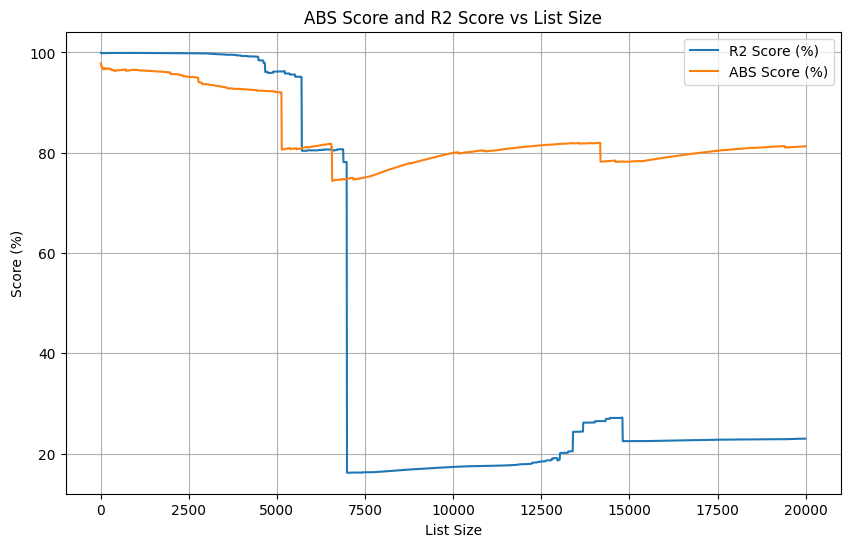

In [148]:
pred_vals = []
test_vals = []
abs_scores = []
r2_scores = []
list_sizes = []
step = 10
max_size = 10000 #len(pred_h4)
for idx in range(0, max_size-step, step):
    list_sizes.append(idx + step)
    pred_vals.extend(list(pred_h4[idx: idx+step]))
    test_vals.extend(list(test_h4[idx: idx+step]))
    yp = np.array(pred_vals); yt = np.array(test_vals)
    abs_scores.append((1 - np.mean(np.abs((yp - yt)/yt)))*100)
    r2_scores.append(metrics.r2_score(yt, yp)*100)
    #yp = pred_h4[:10]; yt = test_h4[:10]
    #print("abs score:", (1 - np.mean(np.abs((yp - yt)/yt)))*100)
    #print("r2 score", metrics.r2_score(yt, yp)*100)

In [ ]:
# Plotting the graph
plt.figure(figsize=(10, 6))
plt.plot(list_sizes, r2_scores, label="R2 Score (%)")
plt.plot(list_sizes, abs_scores, label="ABS Score (%)")
plt.xlabel("List Size")
plt.ylabel("Score (%)")
plt.title("ABS Score and R2 Score vs List Size")
plt.legend()
plt.grid(True)

# Displaying the plot
plt.show()

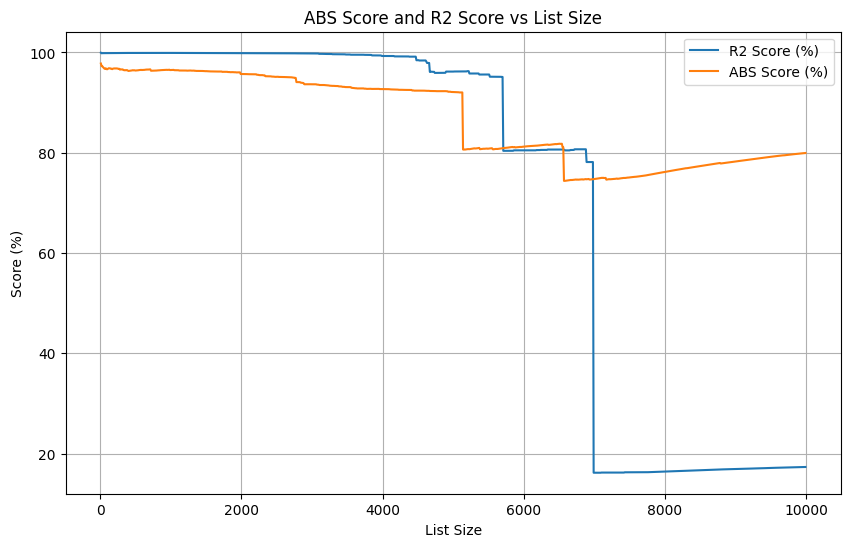
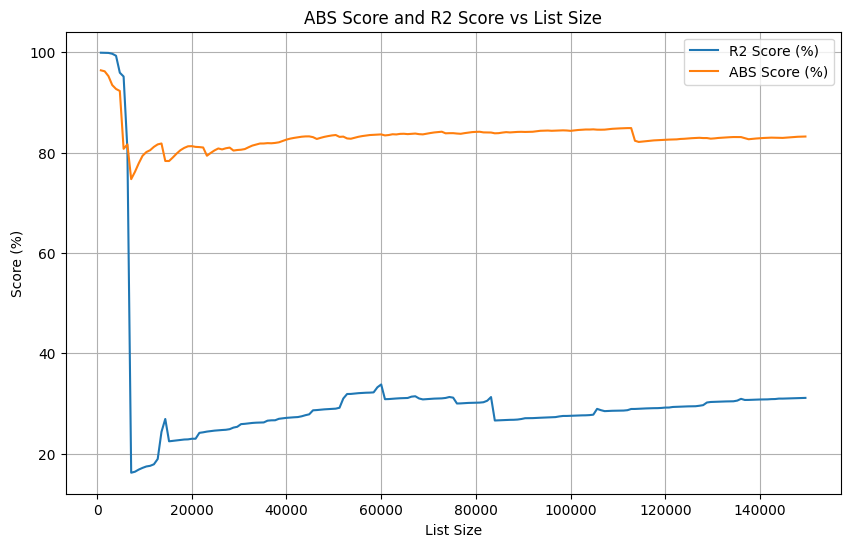

In [160]:
pred_vals = []
test_vals = []
abs_scores = []
r2_scores = []
list_sizes = []
step = 2
max_size = 10000 #len(pred_h4)
for idx in range(0, max_size-step, step):
    list_sizes.append(idx + step)
    pred_vals.extend(list(pred_h4[idx: idx+step]))
    test_vals.extend(list(test_h4[idx: idx+step]))
    yp = np.array(pred_vals); yt = np.array(test_vals)
    abs_scores.append((1 - np.mean(np.abs((yp - yt)/yt)))*100)
    r2_scores.append(metrics.r2_score(yt, yp)*100)
    #yp = pred_h4[:10]; yt = test_h4[:10]
    #print("abs score:", (1 - np.mean(np.abs((yp - yt)/yt)))*100)
    #print("r2 score", metrics.r2_score(yt, yp)*100)

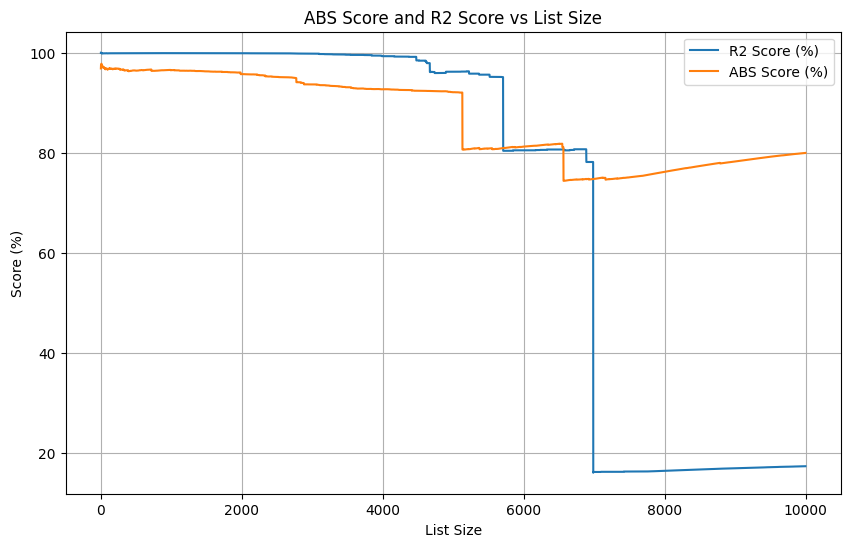

In [161]:
# Plotting the graph
plt.figure(figsize=(10, 6))
plt.plot(list_sizes, r2_scores, label="R2 Score (%)")
plt.plot(list_sizes, abs_scores, label="ABS Score (%)")
plt.xlabel("List Size")
plt.ylabel("Score (%)")
plt.title("ABS Score and R2 Score vs List Size")
plt.legend()
plt.grid(True)

# Displaying the plot
plt.show()

In [131]:
max_size-step

499702

In [124]:
"""for x in range(40):
    print(list(pred_h4[:40])[x], pred_vals[x])"""

'for x in range(40):\n    print(list(pred_h4[:40])[x], pred_vals[x])'

In [99]:
i = 6
test_h2 = df_pred.iloc[:,i].values
pred_h2 = df_pred.iloc[:,i + 2 * num_vars].values
delta_h2 = df_pred.iloc[:,i + 4 * num_vars].values
i = 7
test_h4 = df_pred.iloc[:,i].values
pred_h4 = df_pred.iloc[:,i + 2 * num_vars].values
delta_h4 = df_pred.iloc[:,i + 4 * num_vars].values

In [55]:
import json

In [56]:
print(json.dumps(cfg['test_metrics'], indent=4, sort_keys=True))

{
    "abs_score": {
        "model": 92.19401040521802,
        "y5+y13": 99.65913324207601,
        "y6+y14": 99.85384140154525
    },
    "r2": {
        "model": 99.68743872553405,
        "y5+y13": 37.06732576805645,
        "y6+y14": 20.55278102829835
    }
}


In [46]:
r2_score = metrics.r2_score(y_test, y_pred)*100
abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100

In [47]:
r2_score, abs_score

(99.68743872553405, 92.19401040521802)

In [48]:
y_test, y_pred

(array([[-5.70932596,  5.77025476],
        [ 3.98858783, -3.92026656],
        [-4.81130591,  4.86468391],
        ...,
        [ 1.06954111, -0.62429374],
        [-1.84787842, -0.96410051],
        [ 3.26348714, -2.66593214]]),
 array([[-5.67316251,  5.76737431],
        [ 3.97603567, -3.97760141],
        [-4.77479385,  4.89716677],
        ...,
        [ 1.04845043, -0.63210207],
        [-1.81262109, -0.95641257],
        [ 3.38055384, -2.70640729]]))

In [49]:
metrics.r2_score(y_test, y_pred)

0.9968743872553405

In [50]:
df_pred.iloc[:,i + 4 * num_vars]

0        -0.288530
1         6.020457
2         3.327286
3        -0.239092
4         1.661843
            ...   
499707   -5.054818
499708   -7.751616
499709    1.688105
499710   -1.237883
499711    4.439223
Name: delta_y6+y14, Length: 499712, dtype: float64

In [51]:
100 - np.abs(df_pred.iloc[:,i + 4 * num_vars].mean())

99.85384140154525

In [52]:
test, pred

(array([319.61940199, -49.41388138, 128.62995709, ...,  -0.86692695,
         -1.62242775, -13.38134868]),
 array([318.69720388, -52.38882289, 132.90984412, ...,  -0.88156159,
         -1.60234399, -13.97537652]))

,x1,x2,x3,x4,y5+y13_scaled,y6+y14_scaled,y5+y13,y6+y14,y5+y13_scaled_pred,y6+y14_scaled_pred,y5+y13_pred,y6+y14_pred,scaled_delta_y5+y13,scaled_delta_y6+y14,delta_y5+y13,delta_y6+y14
0,5.434361e-07,0.147431,0.774351,0.245984,-5.709326,5.770255,-300.667662,319.619402,-5.673163,5.767374,-289.953224,318.697204,-0.633410,-0.049919,-3.563549,-0.288530
1,2.254383e-06,0.705441,0.511854,0.034134,3.988588,-3.920267,52.978609,-49.413881,3.976036,-3.977601,52.305295,-52.388823,-0.314702,1.462524,-1.270916,6.020457
2,3.135050e-06,0.348233,0.460954,0.283262,-4.811306,4.864684,-121.891999,128.629957,-4.774794,4.897167,-117.485886,132.909844,-0.758880,0.667728,-3.614767,3.327286
3,3.604113e-06,0.659904,0.123490,0.852356,5.357519,-5.450126,211.197887,-231.787423,5.269550,-5.447742,193.328585,-231.233239,-1.641969,-0.043733,-8.460928,-0.239092
4,3.774481e-06,0.547915,0.649524,0.693039,3.581907,-3.627979,34.942011,-36.636665,3.520905,-3.644026,32.815021,-37.245509,-1.703052,0.442324,-6.087200,1.661843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499707,3.458530e-01,0.084713,0.169534,0.451104,-3.995952,2.075135,-53.377589,6.965623,-4.015327,2.029926,-54.441439,6.613523,0.484871,-2.178610,1.993064,-5.054818
499708,3.460583e-01,0.315792,0.713225,0.709775,-2.072334,0.835396,-6.943338,1.305726,-2.037040,0.790506,-6.667882,1.204511,-1.703066,-5.373480,-3.967205,-7.751616
499709,3.465390e-01,0.609794,0.212700,0.336352,1.069541,-0.624294,1.914042,-0.866927,1.048450,-0.632102,1.853226,-0.881562,-1.971938,1.250746,-3.177337,1.688105
499710,3.465490e-01,0.432198,0.130247,0.729713,-1.847878,-0.964101,-5.346341,-1.622428,-1.812621,-0.956413,-5.126484,-1.602344,-1.907990,-0.797421,-4.112280,-1.237883


In [104]:
print(json.dumps(cfg['test_metrics'], indent=4, sort_keys=True))

{
    "abs_score": {
        "model": 92.19401040521802,
        "y5+y13": 99.65913324207601,
        "y6+y14": 99.85384140154525
    },
    "r2": {
        "model": 99.68743872553405,
        "y5+y13": 37.06732576805645,
        "y6+y14": 20.55278102829835
    }
}


In [133]:
100 - np.mean(np.abs(np.array(df_pred["delta_y5+y13"])))

90.51988588254771

In [123]:
#pr = np.array(df_pred["y5+y13_scaled_pred"])
#te = np.array(df_pred["y5+y13_scaled"])
pr = np.array(df_pred["y5+y13_pred"])
te = np.array(df_pred["y5+y13"])

100 - np.abs(col).mean()
print("abs_score =", (1 - np.mean(np.abs()))) 
#print("r2_score =", metrics.r2_score(te, pr)*100)

UFuncTypeError: ufunc 'absolute' did not contain a loop with signature matching types <class 'numpy.dtypes.StrDType'> -> None

In [120]:
pr = y_pred[:, 1]
te = y_test[:, 1]
print("abs_score = ", (1 - np.mean(np.abs((pr - te)/te)))*100) 
print("r2_score = ", metrics.r2_score(te, pr)*100)

abs_score =  89.75731392872791
r2_score =  99.70966092115503


In [117]:
y_pred_real, y_test_real

(array([[-289.95322381,  318.69720388],
        [  52.30529496,  -52.38882289],
        [-117.48588631,  132.90984412],
        ...,
        [   1.85322641,   -0.88156159],
        [  -5.12648448,   -1.60234399],
        [  28.38704239,  -13.97537652]]),
 array([[-300.66766241,  319.61940199],
        [  52.97860876,  -49.41388138],
        [-121.89199855,  128.62995709],
        ...,
        [   1.91404197,   -0.86692695],
        [  -5.34634098,   -1.62242775],
        [  25.1405342 ,  -13.38134868]]))

In [ ]:
scaled_delta_cname = ['scaled_delta_' + s for s in config['var_y']]
df_pred = pd.concat([df_pred, pd.DataFrame((y_pred - y_test)/y_test*100, columns=scaled_delta_cname)], axis=1)
delta_cname = ['delta_' + s for s in config['var_y']]
df_pred = pd.concat([df_pred, pd.DataFrame((y_pred_real - y_test_real)/y_test_real*100, columns=delta_cname)], axis=1)

In [ ]:
r2_score = metrics.r2_score(y_test, y_pred)*100
abs_score = (1 - np.mean(np.abs((y_pred - y_test)/y_test)))*100

In [ ]:
100 - np.abs(col).mean()

In [3]:
config = {
    "model_type": "skip-light",
    "input_shape": 4,
    "amplitude_shape": 36,
    "data_dir": "/scratch/akula.ha/dataset",
    "seed": 42,
    "var_y": [
        "y5",
        "y6"
    ],
    "activation": "leaky_relu",
    "width": 32,
    "depth": 16,
    "skip_block_layers": 3,
    "beta": 0,
    "alpha": 0,
    "normal_scaled": False,
    "lr_decay_type": "exp",
    "initial_lr": 0.003,
    "final_lr": 1e-06,
    "decay_steps": 120000,
    "train-sample-size": 30000000,
    "validate-sample-size": 500000,
    "test-sample-size": 500000,
    "use_MC_sample": False,
    "batch_size": 1024,
    "steps_per_epoch": 2000,
    "early_stopping_start_epoch": 50,
    "patience": 150,
    "monitor": "val_mse",
    "loss": "mse",
    "gradient_clipping": True,
    "verbose": 1,
    "base_directory": "../models/",
    "epochs": 1,
    "model-uuid": "b8bb7ef8",
    "start_time": "2024-09-30 11:51:21 -0400",
    "device": "cuda",
    "directory": "../models/skip-light-torch-4D-y5_y6-b8bb7ef8",
    "train-samples-used": 6,
    "validate-samples-used": 6,
    "test-samples-used": 6,
    "n_targets": 2,
    "scaling": {},
    "trainable_parameters": 50914,
    "non_trainable_parameters": 0,
    "total_parameters": 50914
}

In [1]:
#  create directory structure
if config['model-uuid'] == "UUID":
    m_uuid = str(uuid.uuid4())[:8]
    config['model-uuid'] = m_uuid
else:
    m_uuid = config['model-uuid']

if config['base_directory'] != '':
    base_directory = config['base_directory'] +'/' if config['base_directory'][-1] != '/' else config['base_directory']
    dir_name = base_directory+config['model_type']+'-torch-'+str(config['input_shape'])+'D'+'-'+'_'.join(config['var_y'])+'-'+m_uuid
else:
    dir_name = config['model_type']+'-torch-'+str(config['input_shape'])+'D'+'-'+'_'.join(config['var_y'])+'-'+m_uuid
if not os.path.exists(dir_name):
    #os.makedirs(dir_name)
config['directory'] = dir_name

# save the config
with open(config['directory']+'/config-'+config['model-uuid']+'-prelim.json', 'w') as f:
    #json.dump(config, f, indent=4)
    pass


NameError: name 'config' is not defined

In [4]:
config['directory'] + f'/dnn-{config["depth"]}-{config["width"]}-{config["activation"]}-adam-{config["lr_decay_type"]}-schedule-{config["loss"]}-{config["monitor"]}.torch'

'../models/skip-light-torch-4D-y5_y6-b8bb7ef8/dnn-16-32-leaky_relu-adam-exp-schedule-mse-val_mse.torch'